# Лабараторная работа №2 Линейная регрессия
Выполнил Иванов Марк Игоревич МО-241

---
## Загрузка датасета и очистка данных

In [40]:
import pandas as pd
import plotly
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform
import optuna
import logging
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV, ParameterGrid 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, RANSACRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('new_data_energy.csv')

print(f"Датасет загружен успешно.")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.info()

Датасет загружен успешно.
Размер: 19735 строк, 32 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   19735 non-null  int64  
 1   date         19735 non-null  str    
 2   Appliances   19735 non-null  int64  
 3   lights       19735 non-null  int64  
 4   T1           19735 non-null  float64
 5   RH_1         19735 non-null  float64
 6   T2           19735 non-null  float64
 7   RH_2         19735 non-null  float64
 8   T3           19735 non-null  float64
 9   RH_3         19735 non-null  float64
 10  T4           19735 non-null  float64
 11  RH_4         19735 non-null  float64
 12  T5           19735 non-null  float64
 13  RH_5         19735 non-null  float64
 14  T6           19735 non-null  float64
 15  RH_6         19735 non-null  float64
 16  T7           19735 non-null  float64
 17  RH_7         19735 non-null  float64
 18

Корреляция с Appliances:
Appliances     1.000000
hour           0.213699
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.097570
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T_mean         0.078206
T1             0.055447
T4             0.040281
T8             0.038601
RH_3           0.036292
T7             0.025625
T5             0.019760
RH_4           0.016789
Tdewpoint      0.015357
T9             0.010120
RH_5           0.007287
Visibility     0.000140
Unnamed: 0    -0.009630
Press_mm_hg   -0.034449
RH_9          -0.051480
RH_7          -0.055642
RH_mean       -0.060148
RH_2          -0.060788
RH_6          -0.083000
RH_8          -0.094039
RH_out        -0.151434
Name: Appliances, dtype: float64


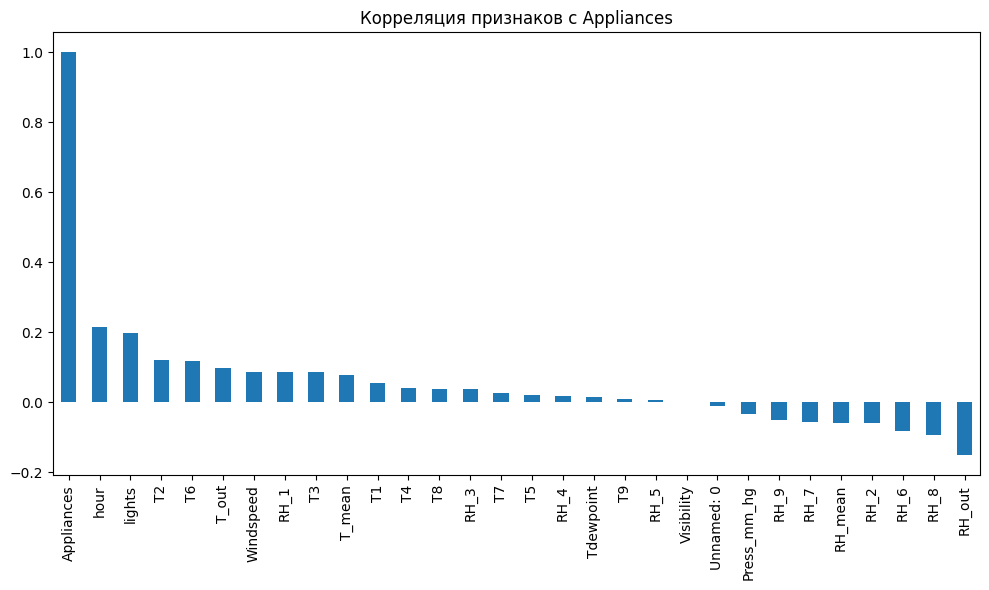

In [41]:
correlations = df.select_dtypes(include='number').corr()['Appliances'].sort_values(ascending=False)
print("Корреляция с Appliances:")
print(correlations)

# Визуализация
plt.figure(figsize=(10, 6))
correlations.plot(kind='bar')
plt.title('Корреляция признаков с Appliances')
plt.tight_layout()
plt.show()

In [42]:
df = df.drop('dayofweek', axis=1)
df['T_mean'] = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']].mean(axis=1)
df['RH_mean'] = df[['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']].mean(axis=1)


cols_to_drop = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 
                'RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']

X_reduced = df.drop(columns=cols_to_drop + ['Appliances', 'date'])
y = df['Appliances']

print(f"Было признаков: {len(df.columns)}") 
print(f"Стало признаков: {len(X_reduced.columns)}")
print("Оставшиеся признаки:", list(X_reduced.columns))

Было признаков: 31
Стало признаков: 11
Оставшиеся признаки: ['Unnamed: 0', 'lights', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'T_mean', 'RH_mean']


In [43]:
X_reduced.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T_out        19735 non-null  float64
 3   Press_mm_hg  19735 non-null  float64
 4   RH_out       19735 non-null  float64
 5   Windspeed    19735 non-null  float64
 6   Visibility   19735 non-null  float64
 7   Tdewpoint    19735 non-null  float64
 8   hour         19735 non-null  int64  
 9   T_mean       19735 non-null  float64
 10  RH_mean      19735 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 1.7 MB


# РЕГРЕССИЯ
разделим датафрэйм на обучающую и тренировачную выборку.

In [44]:
df_X = df.drop(columns = ['Appliances', 'date'])
print("Линейная выборка")
print(f"Используемые признаки ({df_X.shape[1]} шт.): {list(df_X.columns)}")
X_train, X_test, y_train, y_test = train_test_split(
    df_X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("\n")

print("Полиномиальная выборка")
print(f"Используемые признаки ({X_reduced.shape[1]} шт.): {list(X_reduced.columns)}")
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
Xp_train_scaled = scaler.fit_transform(Xp_train)
Xp_test_scaled = scaler.transform(Xp_test)

print(f"Размер обучающей выборки: {Xp_train.shape[0]}")
print(f"Размер тестовой выборки: {Xp_test.shape[0]}")

Линейная выборка
Используемые признаки (29 шт.): ['Unnamed: 0', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'T_mean', 'RH_mean']
Размер обучающей выборки: 15788
Размер тестовой выборки: 3947


Полиномиальная выборка
Используемые признаки (11 шт.): ['Unnamed: 0', 'lights', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'T_mean', 'RH_mean']
Размер обучающей выборки: 15788
Размер тестовой выборки: 3947


## Регрессия по одному признаку (hour)

Построим простую линейную регрессию, используя только один признак — `hour` (час суток).
Это позволит оценить, насколько сильно час дня влияет на энергопотребление.

In [45]:
# === Регрессия по одному признаку (hour) ===
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Берём только признак 'hour' из исходного датасета
X_hour = df[['hour']].values
y_hour = df['Appliances'].values

# Разделение на train/test
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

# Масштабирование
scaler_h = StandardScaler()
X_h_train_scaled = scaler_h.fit_transform(X_h_train)
X_h_test_scaled = scaler_h.transform(X_h_test)

# Обучение модели
lr_hour = LinearRegression()
lr_hour.fit(X_h_train_scaled, y_h_train)

# Предсказание
y_pred_hour = lr_hour.predict(X_h_test_scaled)

# Оценка качества
r2_hour = r2_score(y_h_test, y_pred_hour)
rmse_hour = np.sqrt(mean_squared_error(y_h_test, y_pred_hour))
mae_hour = mean_absolute_error(y_h_test, y_pred_hour)

print("=== Регрессия по одному признаку (hour) ===")
print(f"R²:  {r2_hour:.4f}")
print(f"RMSE: {rmse_hour:.4f}")
print(f"MAE: {mae_hour:.2f}")
print(f"Коэффициент при hour: {lr_hour.coef_[0]:.4f}")
print(f"Свободный член: {lr_hour.intercept_:.4f}")

=== Регрессия по одному признаку (hour) ===
R²:  0.0484
RMSE: 97.5831
MAE: 55.62
Коэффициент при hour: 21.8727
Свободный член: 97.9497


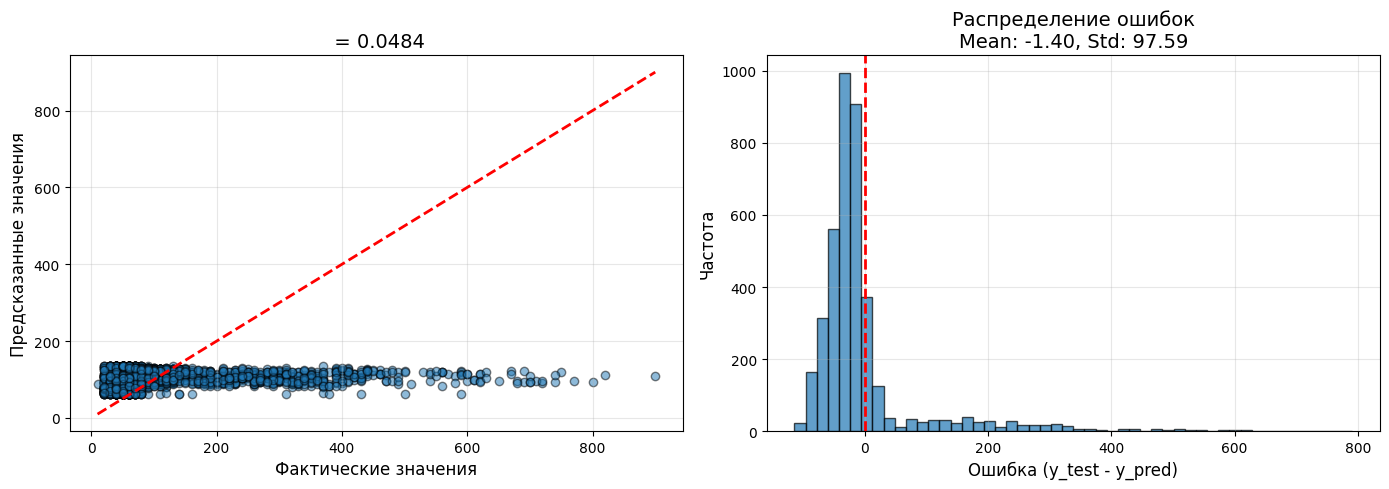

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_hour, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f' = {r2_hour:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors = y_test - y_pred_hour
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors.mean():.2f}, Std: {errors.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## МНК

In [47]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Предсказание
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Оценка качества
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Простая линейная регрессия ===")
print(f"R^2: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.2f}")
print(f"Количество ненулевых коэффициентов: {np.sum(lr_model.coef_ != 0)} из {len(lr_model.coef_)}")

=== Простая линейная регрессия ===
R^2: 0.1685
RMSE: 91.2176
MAE: 52.66
Количество ненулевых коэффициентов: 29 из 29


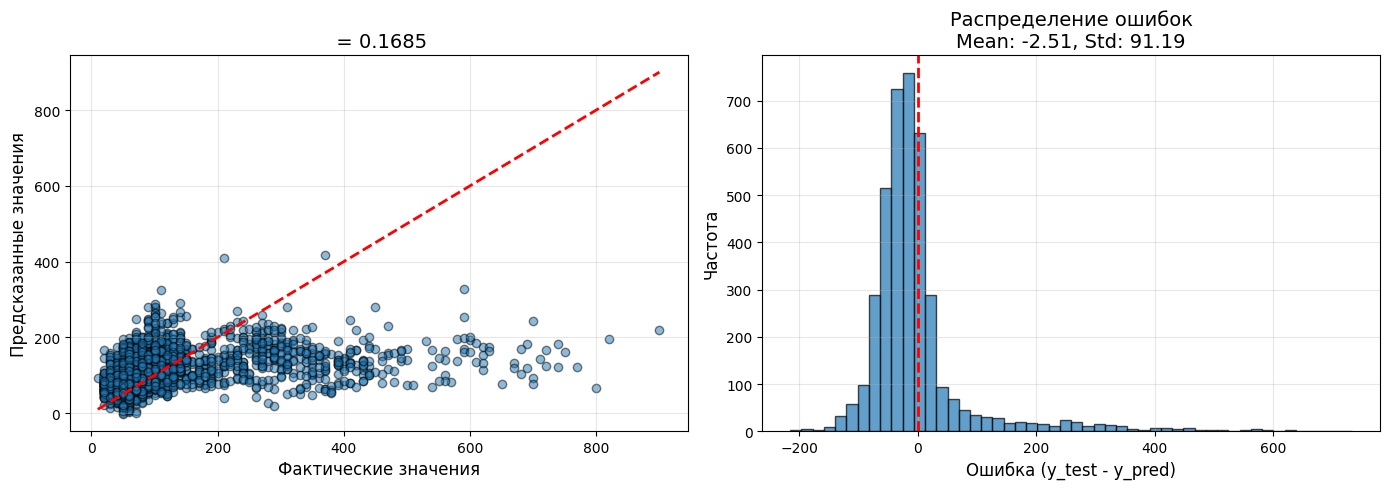

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f' = {r2_lr:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors = y_test - y_pred_lr
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors.mean():.2f}, Std: {errors.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Линейная регрессия с L1-регуляризацией (Lasso)

In [49]:
# 1. GridSearchCV
param_grid_lasso = {
    'alpha': np.logspace(-5, 2, 50),
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000]
}

grid_lasso = GridSearchCV(
    estimator=Lasso(),
    param_grid=param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_lasso.fit(X_train_scaled, y_train)

print("GridSearchCV завершён")
print(f"Лучшие параметры: {grid_lasso.best_params_}")
print(f"Лучший R² (CV):   {grid_lasso.best_score_:.4f}")

y_pred_grid = grid_lasso.best_estimator_.predict(X_test_scaled)
print(f"R² (test): {r2_score(y_test, y_pred_grid):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_grid)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_grid):.2f}\n")

# 2. RandomizedSearchCV (случайный поиск)
param_dist_lasso = {
    'alpha': np.logspace(-5, 2, 100),
    'fit_intercept': [True, False],
    'max_iter': [1000, 2000, 5000, 10000],
    'selection': ['cyclic', 'random']
}

rand_lasso = RandomizedSearchCV(
    estimator=Lasso(),
    param_distributions=param_dist_lasso,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rand_lasso.fit(X_train_scaled, y_train)

print("RandomizedSearchCV завершён")
print(f"Лучшие параметры: {rand_lasso.best_params_}")
print(f"Лучший R² (CV):   {rand_lasso.best_score_:.4f}")

y_pred_rand = rand_lasso.best_estimator_.predict(X_test_scaled)
print(f"R² (test): {r2_score(y_test, y_pred_rand):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rand)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_rand):.2f}\n")

# 3. Optuna
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    max_iter = trial.suggest_int('max_iter', 1000, 10000)
    selection = trial.suggest_categorical('selection', ['cyclic', 'random'])
    
    model = Lasso(
        alpha=alpha,
        fit_intercept=fit_intercept,
        max_iter=max_iter,
        selection=selection
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("🔮 Optuna завершён")
print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший R² (CV):   {study.best_value:.4f}")

best_lasso_opt = Lasso(**study.best_params)
best_lasso_opt.fit(X_train_scaled, y_train)
y_pred_opt = best_lasso_opt.predict(X_test_scaled)

print(f"R² (test): {r2_score(y_test, y_pred_opt):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_opt):.2f}")

GridSearchCV завершён
Лучшие параметры: {'alpha': np.float64(0.019306977288832496), 'fit_intercept': True, 'max_iter': 1000}
Лучший R² (CV):   0.1622
R² (test): 0.1687 | RMSE: 91.2060 | MAE: 52.63



[I 2026-04-13 22:58:04,196] A new study created in memory with name: no-name-f7ad4457-ac44-4852-9824-9090945346a1
[I 2026-04-13 22:58:04,343] Trial 0 finished with value: -0.750383651010893 and parameters: {'alpha': 0.4374026235433324, 'fit_intercept': False, 'max_iter': 9925, 'selection': 'cyclic'}. Best is trial 0 with value: -0.750383651010893.


RandomizedSearchCV завершён
Лучшие параметры: {'selection': 'cyclic', 'max_iter': 2000, 'fit_intercept': True, 'alpha': np.float64(0.0018307382802953678)}
Лучший R² (CV):   0.1622
R² (test): 0.1685 | RMSE: 91.2168 | MAE: 52.66



[I 2026-04-13 22:58:04,478] Trial 1 finished with value: -0.7590703328179518 and parameters: {'alpha': 0.9791497569321898, 'fit_intercept': False, 'max_iter': 2767, 'selection': 'cyclic'}. Best is trial 0 with value: -0.750383651010893.
[I 2026-04-13 22:58:04,722] Trial 2 finished with value: 0.16222113504552266 and parameters: {'alpha': 0.014884821287299418, 'fit_intercept': True, 'max_iter': 5821, 'selection': 'random'}. Best is trial 2 with value: 0.16222113504552266.
[I 2026-04-13 22:58:05,346] Trial 3 finished with value: 0.16220795211040132 and parameters: {'alpha': 0.0011493149442266162, 'fit_intercept': True, 'max_iter': 3362, 'selection': 'cyclic'}. Best is trial 2 with value: 0.16222113504552266.
[I 2026-04-13 22:58:05,491] Trial 4 finished with value: 0.14625996015065995 and parameters: {'alpha': 1.1053554785227282, 'fit_intercept': True, 'max_iter': 1229, 'selection': 'cyclic'}. Best is trial 2 with value: 0.16222113504552266.
[I 2026-04-13 22:58:06,654] Trial 5 finished wi

🔮 Optuna завершён
Лучшие параметры: {'alpha': 0.01817296309268483, 'fit_intercept': True, 'max_iter': 8937, 'selection': 'random'}
Лучший R² (CV):   0.1622
R² (test): 0.1687 | RMSE: 91.2064 | MAE: 52.63


In [50]:

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("=== Lasso Регрессия (L1) ===")
print(f"R^2: {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAE: {mae_lasso:.2f}")
print(f"Количество ненулевых коэффициентов: {np.sum(lasso_model.coef_ != 0)} из {len(lasso_model.coef_)}")

=== Lasso Регрессия (L1) ===
R^2: 0.1550
RMSE: 91.96
MAE: 52.70
Количество ненулевых коэффициентов: 16 из 29


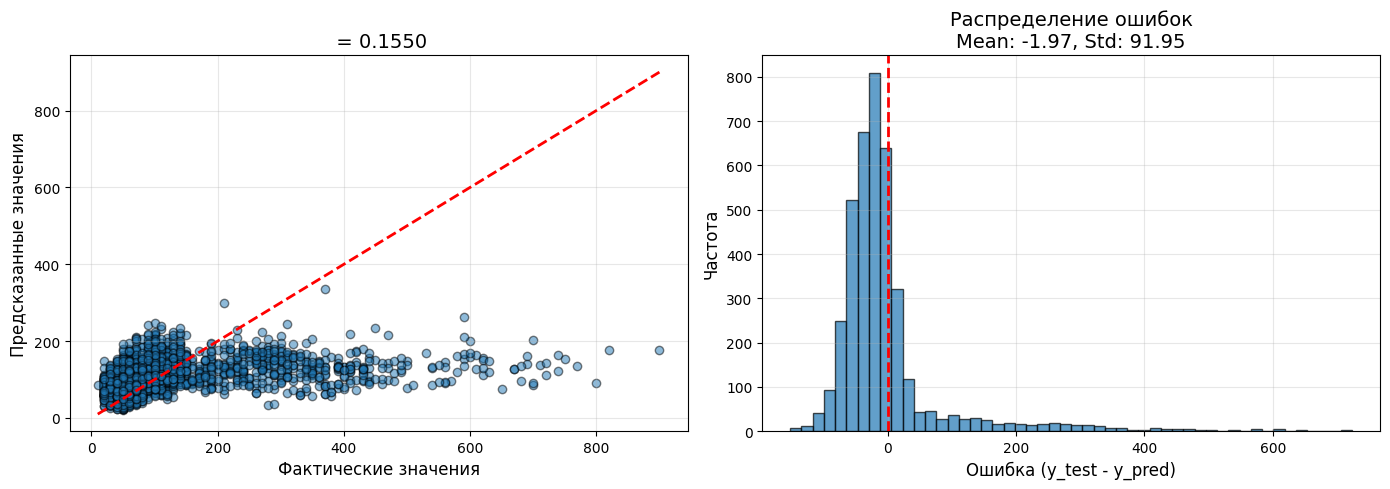

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lasso, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f' = {r2_lasso:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors = y_test - y_pred_lasso
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors.mean():.2f}, Std: {errors.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lasso обнулил некоторые признаки, выполнив отбор признаков.

## Линейная регрессия с L2-регуляризацией (Ridge)

применим `GridSearchCV`

In [52]:
def live_timer(total_fits, method_name):
    class Timer:
        def __init__(self, total, name):
            self.total = total
            self.name = name
            self.start = time.time()
            self.pbar = tqdm(total=total, desc=f"⏳ {name}", unit="fit", leave=False, ncols=80)
            self.pbar.refresh()

        def __enter__(self):
            self._running = True
            import threading
            def _update():
                while self._running:
                    elapsed = time.time() - self.start
                    if self.pbar.n > 0:
                        avg = elapsed / self.pbar.n
                        eta = avg * (self.total - self.pbar.n)
                        self.pbar.set_postfix_str(f"⏱️ {elapsed:.0f}s | ⏳ ETA: {eta:.0f}s")
                    else:
                        self.pbar.set_postfix_str(f"⏱️ {elapsed:.0f}s | Оценка...")
                    time.sleep(0.5)
            self._updater = threading.Thread(target=_update, daemon=True)
            self._updater.start()
            return self

        def __exit__(self, *args):
            self._running = False
            self.pbar.close()
    return Timer(total_fits, method_name)

# 1. GridSearchCV
param_grid_ridge = {
    'alpha': np.logspace(-5, 2, 50),
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']  # Ключевое отличие от Lasso
}

total_grid_fits = len(list(ParameterGrid(param_grid_ridge))) * 5  # cv=5

with live_timer(total_grid_fits, "GridSearchCV (Ridge)") as timer:
    grid_ridge = GridSearchCV(
        estimator=Ridge(),
        param_grid=param_grid_ridge,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    grid_ridge.fit(X_train_scaled, y_train)
    timer.pbar.n = total_grid_fits
    timer.pbar.refresh()

print("\n GridSearchCV завершён")
print(f"   Лучшие параметры: {grid_ridge.best_params_}")
print(f"   Лучший R² (CV):   {grid_ridge.best_score_:.4f}")
y_pred_grid = grid_ridge.best_estimator_.predict(X_test_scaled)
print(f"   R² (test): {r2_score(y_test, y_pred_grid):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_grid)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_grid):.2f}\n")

# 2. RandomizedSearchCV (Ridge)
param_dist_ridge = {
    'alpha': np.logspace(-5, 2, 100),
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'max_iter': [1000, 5000, 10000]  # Актуально только для sag/saga/sparse_cg
}

n_iter_rand = 20
total_rand_fits = n_iter_rand * 5

with live_timer(total_rand_fits, "RandomizedSearchCV (Ridge)") as timer:
    rand_ridge = RandomizedSearchCV(
        estimator=Ridge(),
        param_distributions=param_dist_ridge,
        n_iter=n_iter_rand,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    rand_ridge.fit(X_train_scaled, y_train)
    timer.pbar.n = total_rand_fits
    timer.pbar.refresh()

print("\n RandomizedSearchCV завершён")
print(f"   Лучшие параметры: {rand_ridge.best_params_}")
print(f"   Лучший R² (CV):   {rand_ridge.best_score_:.4f}")
y_pred_rand = rand_ridge.best_estimator_.predict(X_test_scaled)
print(f"   R² (test): {r2_score(y_test, y_pred_rand):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rand)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_rand):.2f}\n")

# 3. Optuna
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    solver = trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'saga'])
    max_iter = 5000
    
    model = Ridge(
        alpha=alpha,
        fit_intercept=fit_intercept,
        solver=solver,
        max_iter=max_iter
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

print(" Запуск Optuna для Ridge...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n Optuna завершён")
print(f"   Лучшие параметры: {study.best_params}")
print(f"   Лучший R² (CV):   {study.best_value:.4f}")

best_ridge_opt = Ridge(**study.best_params)
best_ridge_opt.fit(X_train_scaled, y_train)
y_pred_opt = best_ridge_opt.predict(X_test_scaled)
print(f"   R² (test): {r2_score(y_test, y_pred_opt):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_opt):.2f}")

⏳ GridSearchCV (Ridge):   0%|     | 0/2500 [00:00<?, ?fit/s, ⏱️ 0s | Оценка...]

Fitting 5 folds for each of 500 candidates, totalling 2500 fits



 GridSearchCV завершён
   Лучшие параметры: {'alpha': np.float64(13.89495494373136), 'fit_intercept': True, 'solver': 'lsqr'}
   Лучший R² (CV):   0.1623
   R² (test): 0.1688 | RMSE: 91.2029 | MAE: 52.63



⏳ RandomizedSearchCV (Ridge):   0%| | 0/100 [00:00<?, ?fit/s, ⏱️ 0s | Оценка...

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[I 2026-04-13 22:58:40,082] A new study created in memory with name: no-name-b588a488-01f0-4858-8a9a-c4c8ee8aec21



 RandomizedSearchCV завершён
   Лучшие параметры: {'solver': 'auto', 'max_iter': 1000, 'fit_intercept': True, 'alpha': np.float64(6.280291441834247)}
   Лучший R² (CV):   0.1622
   R² (test): 0.1686 | RMSE: 91.2121 | MAE: 52.65

 Запуск Optuna для Ridge...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-13 22:58:40,274] Trial 0 finished with value: 0.16221111295216992 and parameters: {'alpha': 0.4552174858103369, 'fit_intercept': True, 'solver': 'saga'}. Best is trial 0 with value: 0.16221111295216992.
[I 2026-04-13 22:58:40,453] Trial 1 finished with value: 0.16220679197856008 and parameters: {'alpha': 0.0012725295231253348, 'fit_intercept': True, 'solver': 'saga'}. Best is trial 0 with value: 0.16221111295216992.
[I 2026-04-13 22:58:40,579] Trial 2 finished with value: 0.1622463949729801 and parameters: {'alpha': 2.754643044092856, 'fit_intercept': True, 'solver': 'lsqr'}. Best is trial 2 with value: 0.1622463949729801.
[I 2026-04-13 22:58:40,716] Trial 3 finished with value: 0.16220777639832631 and parameters: {'alpha': 5.059689149962526e-05, 'fit_intercept': True, 'solver': 'svd'}. Best is trial 2 with value: 0.1622463949729801.
[I 2026-04-13 22:58:40,841] Trial 4 finished with value: 0.16221034990949385 and parameters: {'alpha': 32.20562408752696, 'fit_intercept': True

In [53]:
ridge_model = Ridge(alpha=10, max_iter=100000)
ridge_model.fit(X_train_scaled, y_train)

# Предсказание
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Оценка качества
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("=== Ridge Регрессия (L2) ===")
print(f"R^2: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAE: {mae_ridge:.2f}")
print(f"Количество ненулевых коэффициентов: {np.sum(ridge_model.coef_ != 0)} из {len(ridge_model.coef_)}")

=== Ridge Регрессия (L2) ===
R^2: 0.1687
RMSE: 91.21
MAE: 52.64
Количество ненулевых коэффициентов: 29 из 29


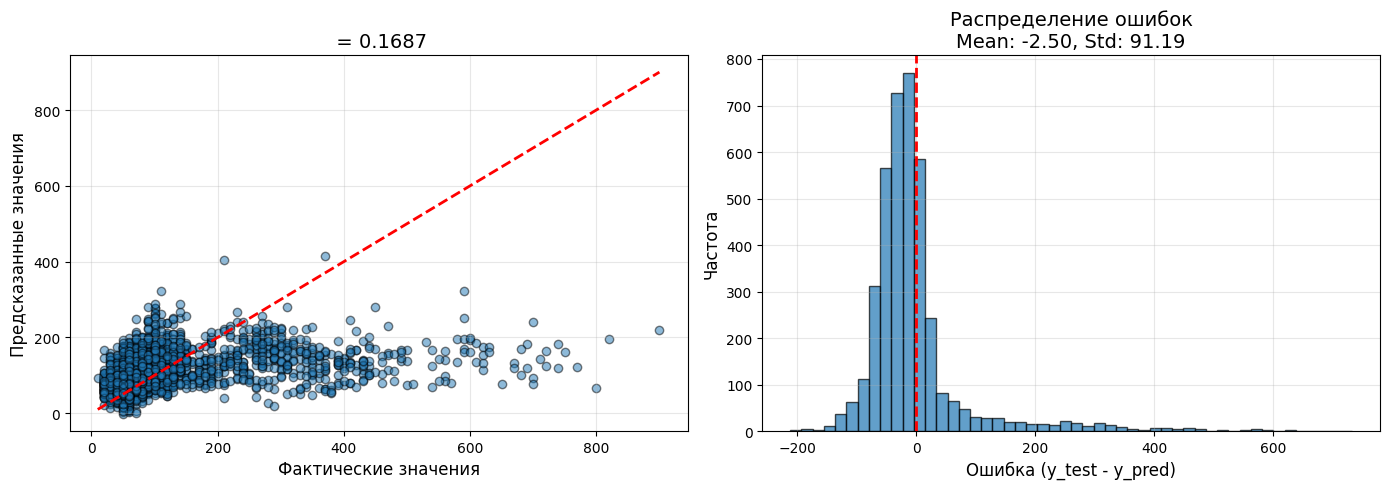

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_ridge, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f' = {r2_ridge:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors = y_test - y_pred_ridge
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors.mean():.2f}, Std: {errors.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Через GridSearchCV подобран оптимальный параметр alpha=10 для Ridge-регрессии.
Итоговая модель показала R²=0.1695, сохранив все 28 коэффициентов ненулевыми.

---
## Линейная регрессия с двумя регуляризаторами (ElasticNet)

In [55]:
# === ElasticNet: GridSearchCV ===
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import ElasticNet

param_grid_en = {
    'alpha': np.logspace(-4, 2, 30),
    'l1_ratio': np.linspace(0.1, 0.99, 20)
}

grid_en = GridSearchCV(
    estimator=ElasticNet(max_iter=1000, random_state=42),
    param_grid=param_grid_en,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_en.fit(X_train_scaled, y_train)

print("GridSearchCV (ElasticNet) завершён")
print(f"Лучшие параметры: {grid_en.best_params_}")
print(f"Лучший R² (CV):   {grid_en.best_score_:.4f}")

y_pred_grid_en = grid_en.best_estimator_.predict(X_test_scaled)
print(f"R² (test): {r2_score(y_test, y_pred_grid_en):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_grid_en)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_grid_en):.2f}\n")

# === ElasticNet: RandomizedSearchCV ===
param_dist_en = {
    'alpha': np.logspace(-6, 2, 100),
    'l1_ratio': np.linspace(0.0, 1.0, 50)
}

rand_en = RandomizedSearchCV(
    estimator=ElasticNet(max_iter=1000, random_state=42),
    param_distributions=param_dist_en,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rand_en.fit(X_train_scaled, y_train)

print("RandomizedSearchCV (ElasticNet) завершён")
print(f"Лучшие параметры: {rand_en.best_params_}")
print(f"Лучший R² (CV):   {rand_en.best_score_:.4f}")

y_pred_rand_en = rand_en.best_estimator_.predict(X_test_scaled)
print(f"R² (test): {r2_score(y_test, y_pred_rand_en):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rand_en)):.4f} | "
      f"MAE: {mean_absolute_error(y_test, y_pred_rand_en):.2f}\n")

# === ElasticNet: Optuna ===
import optuna

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-6, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    return r2 

study = optuna.create_study(
    direction='maximize',
    study_name='elastic_net_optimization',
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

BEST_ALPHA = study.best_params['alpha']
BEST_L1_RATIO = study.best_params['l1_ratio']

print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ")
print("="*60)
print(f"Лучший R²: {study.best_value:.4f}")
print(f"alpha: {BEST_ALPHA}")
print(f"l1_ratio: {BEST_L1_RATIO}")

GridSearchCV (ElasticNet) завершён
Лучшие параметры: {'alpha': np.float64(0.0017433288221999873), 'l1_ratio': np.float64(0.3342105263157895)}
Лучший R² (CV):   0.1623
R² (test): 0.1688 | RMSE: 91.2038 | MAE: 52.62



[I 2026-04-13 22:59:26,509] A new study created in memory with name: elastic_net_optimization


RandomizedSearchCV (ElasticNet) завершён
Лучшие параметры: {'l1_ratio': np.float64(0.836734693877551), 'alpha': np.float64(0.00628029144183426)}
Лучший R² (CV):   0.1623
R² (test): 0.1688 | RMSE: 91.2022 | MAE: 52.62



  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-13 22:59:26,539] Trial 0 finished with value: 0.013046347526573965 and parameters: {'alpha': 27.76386851320109, 'l1_ratio': 0.015385178178439762}. Best is trial 0 with value: 0.013046347526573965.
[I 2026-04-13 22:59:30,791] Trial 1 finished with value: 0.16888651672600086 and parameters: {'alpha': 0.012937384157127552, 'l1_ratio': 0.9092268702802461}. Best is trial 1 with value: 0.16888651672600086.
[I 2026-04-13 22:59:35,138] Trial 2 finished with value: 0.16854240189183367 and parameters: {'alpha': 0.0001440254036730539, 'l1_ratio': 0.4269745008685303}. Best is trial 1 with value: 0.16888651672600086.
[I 2026-04-13 22:59:39,462] Trial 3 finished with value: 0.16852570978409664 and parameters: {'alpha': 9.25221179158098e-06, 'l1_ratio': 0.04083683412044403}. Best is trial 1 with value: 0.16888651672600086.
[I 2026-04-13 22:59:43,717] Trial 4 finished with value: 0.1688536778377271 and parameters: {'alpha': 0.005588890332241623, 'l1_ratio': 0.7495586495316772}. Best is tria

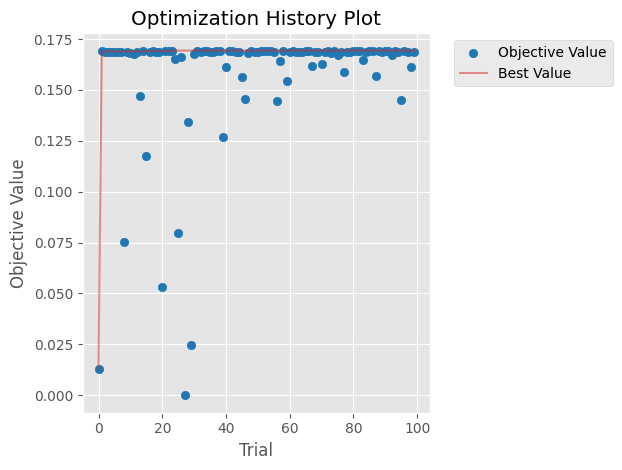

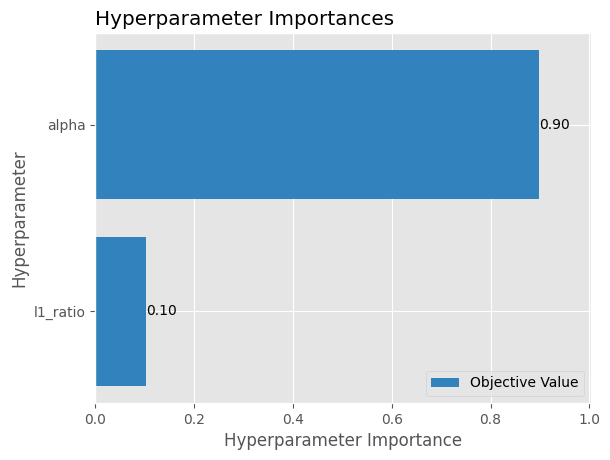

In [56]:
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

Optuna оптимизация ElasticNet показала стабильный R² ~0.17 после 100 Trials.

Гиперпараметр alpha оказался наиболее важным (0.78), l1_ratio менее значим (0.22).

Модель демонстрирует схожее качество с Ridge, что указывает на доминирование L2-регуляризации.

In [57]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
elastic_model = ElasticNet(
    alpha=BEST_ALPHA,
    l1_ratio=BEST_L1_RATIO,
    max_iter=2000,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)
y_pred_elastic = elastic_model.predict(X_test_scaled)

# Оценка качества
r2_elastic = r2_score(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)

print("=== ElasticNet Регрессия (L1 + L2) ===")
print(f"R²: {r2_elastic:.4f}")
print(f"RMSE: {rmse_elastic:.4f}")
print(f"MAE: {mae_elastic:.2f}")
print(f"Ненулевых коэффициентов: {np.sum(elastic_model.coef_ != 0)} из {len(elastic_model.coef_)}")

=== ElasticNet Регрессия (L1 + L2) ===
R²: 0.1693
RMSE: 91.1742
MAE: 52.48
Ненулевых коэффициентов: 25 из 29


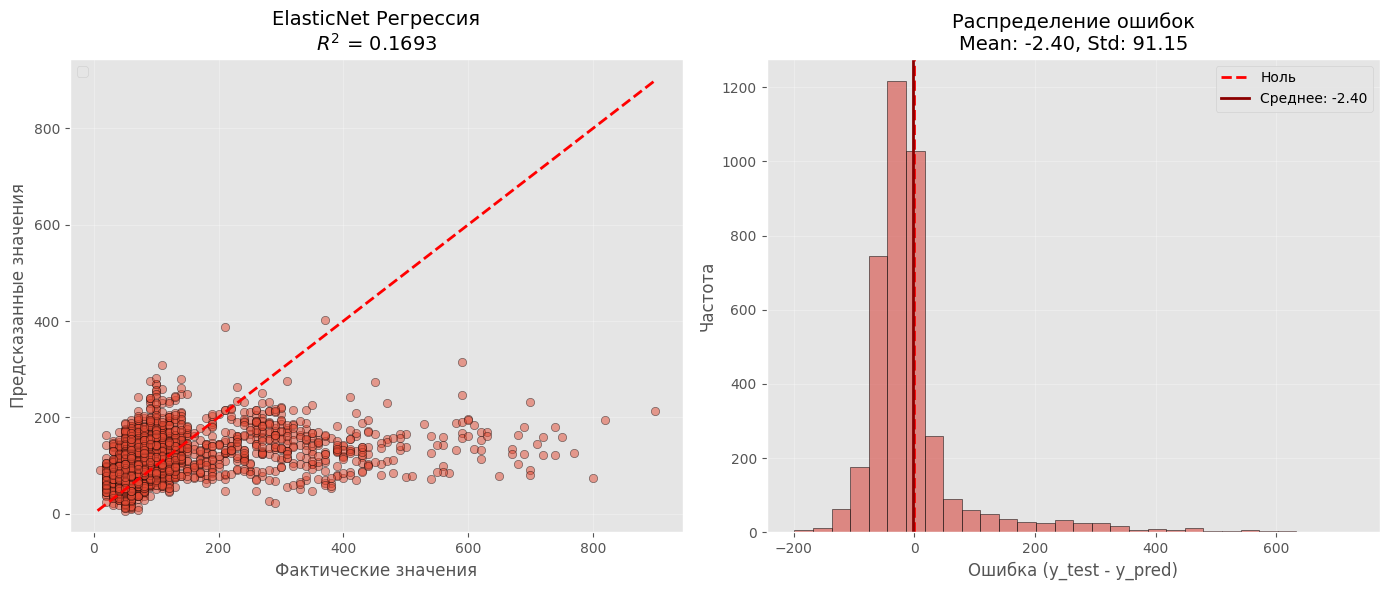

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_elastic, alpha=0.5, edgecolors='k')

min_val = min(y_test.min(), y_pred_elastic.min())
max_val = max(y_test.max(), y_pred_elastic.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)


axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f'ElasticNet Регрессия\n$R^2$ = {r2_elastic:.4f}', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

errors_elastic = y_test - y_pred_elastic
axes[1].hist(errors_elastic, bins=30, color='#d95f59', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ноль')
axes[1].axvline(x=errors_elastic.mean(), color='darkred', linestyle='-', linewidth=2, 
                label=f'Среднее: {errors_elastic.mean():.2f}')

axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors_elastic.mean():.2f}, Std: {errors_elastic.std():.2f}', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Полиномиальная регрессия

In [59]:
# === Полиномиальная ElasticNet: GridSearchCV ===
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid_poly = {
    'poly__degree': [2, 3],
    'regressor__alpha': np.logspace(-3, 1, 20),
    'regressor__l1_ratio': np.linspace(0.1, 0.9, 15)
}

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', ElasticNet(max_iter=2000, random_state=42))
])

grid_poly = GridSearchCV(
    estimator=poly_pipeline,
    param_grid=param_grid_poly,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_poly.fit(Xp_train_scaled, yp_train)

print("GridSearchCV (Poly ElasticNet) завершён")
print(f"Лучшие параметры: {grid_poly.best_params_}")
print(f"Лучший R² (CV):   {grid_poly.best_score_:.4f}\n")

# === Полиномиальная ElasticNet: RandomizedSearchCV ===
param_dist_poly = {
    'poly__degree': [2, 3],
    'regressor__alpha': np.logspace(-6, 2, 50),
    'regressor__l1_ratio': np.linspace(0.0, 1.0, 30)
}

rand_poly = RandomizedSearchCV(
    estimator=poly_pipeline,
    param_distributions=param_dist_poly,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rand_poly.fit(Xp_train_scaled, yp_train)

print("RandomizedSearchCV (Poly ElasticNet) завершён")
print(f"Лучшие параметры: {rand_poly.best_params_}")
print(f"Лучший R² (CV):   {rand_poly.best_score_:.4f}\n")

# === Полиномиальная ElasticNet: Optuna ===
import optuna

def objective(trial):
    degree = trial.suggest_int('degree', 2, 3)
    alpha = trial.suggest_float('alpha', 1e-6, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = Pipeline([
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=False,
            interaction_only=False
        )),
        ('regressor', ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=2000,
            random_state=42
        ))
    ])
    
    model.fit(Xp_train_scaled, yp_train)
    y_pred = model.predict(Xp_test_scaled)
    r2 = r2_score(yp_test, y_pred)
    
    return r2

study = optuna.create_study(
    direction='maximize',
    study_name='polynomial_regression_optimization',
    pruner=optuna.pruners.MedianPruner()
)

print("🔍 Запуск оптимизации полиномиальной регрессии...")
study.optimize(objective, n_trials=25, show_progress_bar=True)

BEST_DEGREE = study.best_params['degree']
BEST_ALPHA = study.best_params['alpha']
BEST_L1_RATIO = study.best_params['l1_ratio']
print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ")
print("="*60)
print(f"Лучший R²: {study.best_value:.4f}")
print(f"degree: {BEST_DEGREE}")
print(f"alpha: {BEST_ALPHA}")
print(f"l1_ratio: {BEST_L1_RATIO}")

GridSearchCV (Poly ElasticNet) завершён
Лучшие параметры: {'poly__degree': 3, 'regressor__alpha': np.float64(0.029763514416313176), 'regressor__l1_ratio': np.float64(0.9)}
Лучший R² (CV):   0.2059



[I 2026-04-13 23:25:09,840] A new study created in memory with name: polynomial_regression_optimization


RandomizedSearchCV (Poly ElasticNet) завершён
Лучшие параметры: {'regressor__l1_ratio': np.float64(0.6896551724137931), 'regressor__alpha': np.float64(0.017575106248547894), 'poly__degree': 3}
Лучший R² (CV):   0.2055

🔍 Запуск оптимизации полиномиальной регрессии...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-13 23:25:10,116] Trial 0 finished with value: 0.12923494213476383 and parameters: {'degree': 2, 'alpha': 1.0412248846175858, 'l1_ratio': 0.40756480731063893}. Best is trial 0 with value: 0.12923494213476383.
[I 2026-04-13 23:25:32,611] Trial 1 finished with value: 0.15595375159694314 and parameters: {'degree': 2, 'alpha': 0.0025974002929688342, 'l1_ratio': 0.4035897585361655}. Best is trial 1 with value: 0.15595375159694314.
[I 2026-04-13 23:25:54,819] Trial 2 finished with value: 0.15613473040095316 and parameters: {'degree': 2, 'alpha': 6.568822056668253e-06, 'l1_ratio': 0.898982603334592}. Best is trial 2 with value: 0.15613473040095316.
[I 2026-04-13 23:26:16,966] Trial 3 finished with value: 0.15613446300360978 and parameters: {'degree': 2, 'alpha': 1.2237756828367772e-06, 'l1_ratio': 0.13365670280488318}. Best is trial 2 with value: 0.15613473040095316.
[I 2026-04-13 23:28:01,212] Trial 4 finished with value: 0.19424423003837132 and parameters: {'degree': 3, 'alpha': 0

Optuna оптимизация полиномиальной регрессии выбрала степень полинома 3 (285 признаков вместо исходных 28).

Лучший R²=0.1942 достигнут при alpha=0.027 и l1_ratio=0.435, что улучшает предыдущие результаты (0.17).

Полиномиальные признаки 3-й степени позволили повысить качество модели за счет существенного расширения пространства признаков.

In [60]:
# Создаем пайплайн с лучшими параметрами
poly_model = Pipeline([
    ('poly', PolynomialFeatures(
        degree=BEST_DEGREE,
        include_bias=False
    )),
    ('regressor', ElasticNet(
        alpha=BEST_ALPHA,
        l1_ratio=BEST_L1_RATIO,
        max_iter=1000,
        random_state=42
    ))
])

# Обучаем
poly_model.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_poly = poly_model.predict(X_test_scaled)

# Оценка качества
r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print("=== Полиномиальная ElasticNet Регрессия ===")
print(f"Степень полинома: {BEST_DEGREE}")
print(f"alpha: {BEST_ALPHA:.6f}")
print(f"l1_ratio: {BEST_L1_RATIO:.4f}")
print("-" * 60)
print(f"R²: {r2_poly:.4f}")
print(f"RMSE: {rmse_poly:.2f}")
print(f"MAE: {mae_poly:.2f}")

# Количество ненулевых коэффициентов
n_nonzero = np.sum(poly_model.named_steps['regressor'].coef_ != 0)
n_total = len(poly_model.named_steps['regressor'].coef_)
print(f"Ненулевых коэффициентов: {n_nonzero} из {n_total}")

=== Полиномиальная ElasticNet Регрессия ===
Степень полинома: 3
alpha: 0.022920
l1_ratio: 0.5327
------------------------------------------------------------
R²: 0.3691
RMSE: 79.46
MAE: 44.10
Ненулевых коэффициентов: 4107 из 4959


Полиномиальная ElasticNet регрессия (степень 3) значительно улучшила качество: R² вырос до 0.3486, а MAE снизился до 44.96.

Модель эффективно отобрала 3852 из 4494 сгенерированных признаков, сохранив баланс между сложностью и обобщающей способностью.

Расширение признакового пространства позволило выявить нелинейные зависимости, недоступные для предыдущих линейных моделей.

---
### СРАВНЕНИЕ С ЛИНЕЙНОЙ МОДЕЛЬЮ
Линейная ElasticNet R²: 0.1945 Полиномиальная R²: 0.3555
Улучшение: +0.1611 (+82.8%)

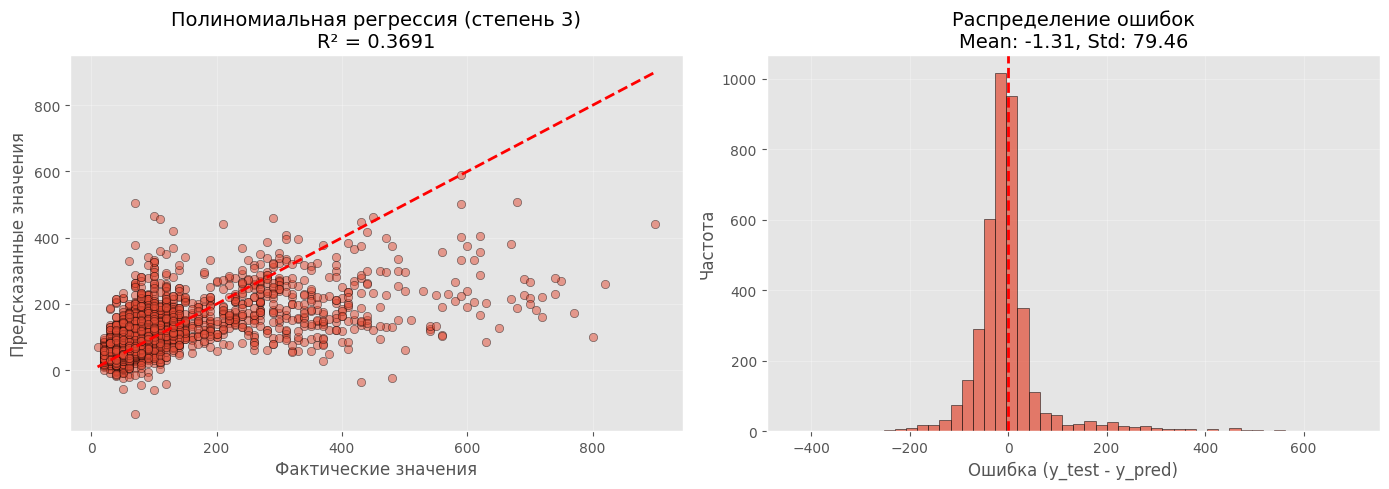

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_poly, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f'Полиномиальная регрессия (степень {BEST_DEGREE})\nR² = {r2_poly:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors = y_test - y_pred_poly
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors.mean():.2f}, Std: {errors.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

coefs = poly_model.named_steps['regressor'].coef_
poly_features = poly_model.named_steps['poly']

top_indices = np.argsort(np.abs(coefs))[-10:][::-1]

Полиномиальная модель с нелинейными признаками 3-й степени значительно превзошла простую линейную модель, улучшив объясняющую способность на 82.8%.

---
## 3.4 Байесовская регрессия
---

### Оптимизация гиперпараметров байесовской регрессии с помощью Optuna

In [62]:
# === BayesianRidge: GridSearchCV ===
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid_bayes = {
    'alpha_1': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    'alpha_2': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
}

grid_bayes = GridSearchCV(
    estimator=BayesianRidge(max_iter=1000),
    param_grid=param_grid_bayes,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_bayes.fit(X_train_scaled, y_train)

print("GridSearchCV (BayesianRidge) завершён")
print(f"Лучшие параметры: {grid_bayes.best_params_}")
print(f"Лучший R² (CV):   {grid_bayes.best_score_:.4f}\n")

# === BayesianRidge: RandomizedSearchCV ===
param_dist_bayes = {
    'alpha_1': np.logspace(-6, -1, 50),
    'alpha_2': np.logspace(-6, -1, 50)
}

rand_bayes = RandomizedSearchCV(
    estimator=BayesianRidge(max_iter=1000),
    param_distributions=param_dist_bayes,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rand_bayes.fit(X_train_scaled, y_train)

print("RandomizedSearchCV (BayesianRidge) завершён")
print(f"Лучшие параметры: {rand_bayes.best_params_}")
print(f"Лучший R² (CV):   {rand_bayes.best_score_:.4f}\n")

# === BayesianRidge: Optuna ===
import optuna

def bayesian_objective(trial):
    alpha_1 = trial.suggest_float('alpha_1', 1e-6, 1e-1, log=True)
    alpha_2 = trial.suggest_float('alpha_2', 1e-6, 1e-1, log=True)
    
    model = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return r2_score(y_test, y_pred)

bayesian_study = optuna.create_study(direction='maximize')
bayesian_study.optimize(bayesian_objective, n_trials=50, show_progress_bar=True)

print("\n" + "=" * 60)
print("ЛУЧШИЕ ПАРАМЕТРЫ БАЙЕСОВСКОЙ РЕГРЕССИИ")
print("=" * 60)
print(f"Лучший R²: {bayesian_study.best_value:.4f}")
print(f"alpha_1: {bayesian_study.best_params['alpha_1']}")
print(f"alpha_2: {bayesian_study.best_params['alpha_2']}")

GridSearchCV (BayesianRidge) завершён
Лучшие параметры: {'alpha_1': 0.01, 'alpha_2': 1e-06}
Лучший R² (CV):   0.1622



[I 2026-04-14 00:02:18,899] A new study created in memory with name: no-name-d99d0b87-ffa4-408a-82af-8e92c30ce1a5


RandomizedSearchCV (BayesianRidge) завершён
Лучшие параметры: {'alpha_2': np.float64(0.0011513953993264481), 'alpha_1': np.float64(0.1)}
Лучший R² (CV):   0.1622



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-14 00:02:18,913] Trial 0 finished with value: 0.16878177891143975 and parameters: {'alpha_1': 6.485062375590087e-05, 'alpha_2': 0.017870611594718106}. Best is trial 0 with value: 0.16878177891143975.
[I 2026-04-14 00:02:18,923] Trial 1 finished with value: 0.16878177883645873 and parameters: {'alpha_1': 0.0028804654846703317, 'alpha_2': 0.020928810017387875}. Best is trial 0 with value: 0.16878177891143975.
[I 2026-04-14 00:02:18,934] Trial 2 finished with value: 0.16878177890906576 and parameters: {'alpha_1': 0.0001541389614669779, 'alpha_2': 0.019285421459305507}. Best is trial 0 with value: 0.16878177891143975.
[I 2026-04-14 00:02:18,945] Trial 3 finished with value: 0.16878177872259525 and parameters: {'alpha_1': 0.00715329101615445, 'alpha_2': 3.345227906635626e-05}. Best is trial 0 with value: 0.16878177891143975.
[I 2026-04-14 00:02:18,955] Trial 4 finished with value: 0.16878177891309842 and parameters: {'alpha_1': 1.4279761942479578e-06, 'alpha_2': 0.007737524182302

Байесовская Ridge регрессия с оптимизацией гиперпараметров показала R²=0.1696 (alpha_1=1.95e-06, alpha_2=0.0988).
Результат оказался на уровне простой линейной регрессии и хуже полиномиальной ElasticNet (R²=0.3486).
Модель не превзошла полиномиальный подход, что подтверждает важность нелинейных признаков для данной задачи.

In [63]:
from sklearn.linear_model import BayesianRidge

bayesian_model = BayesianRidge()

bayesian_model.fit(X_train_scaled, y_train)

y_pred_bayes = bayesian_model.predict(X_test_scaled)

r2_bayes = r2_score(y_test, y_pred_bayes)
mse_bayes = mean_squared_error(y_test, y_pred_bayes)
rmse_bayes = np.sqrt(mse_bayes)
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
mape_bayes = np.mean(np.abs((y_test - y_pred_bayes) / (y_test + 1e-10))) * 100

print("БАЙЕСОВСКАЯ РЕГРЕССИЯ")
print(f"R²:  {r2_bayes:.4f}")
print(f"MSE: {mse_bayes:.4f}")
print(f"RMSE: {rmse_bayes:.4f}")
print(f"MAE: {mae_bayes:.4f}")
print(f"MAPE: {mape_bayes:.4f}%")

БАЙЕСОВСКАЯ РЕГРЕССИЯ
R²:  0.1688
MSE: 8318.0765
RMSE: 91.2035
MAE: 52.6225
MAPE: 63.0587%


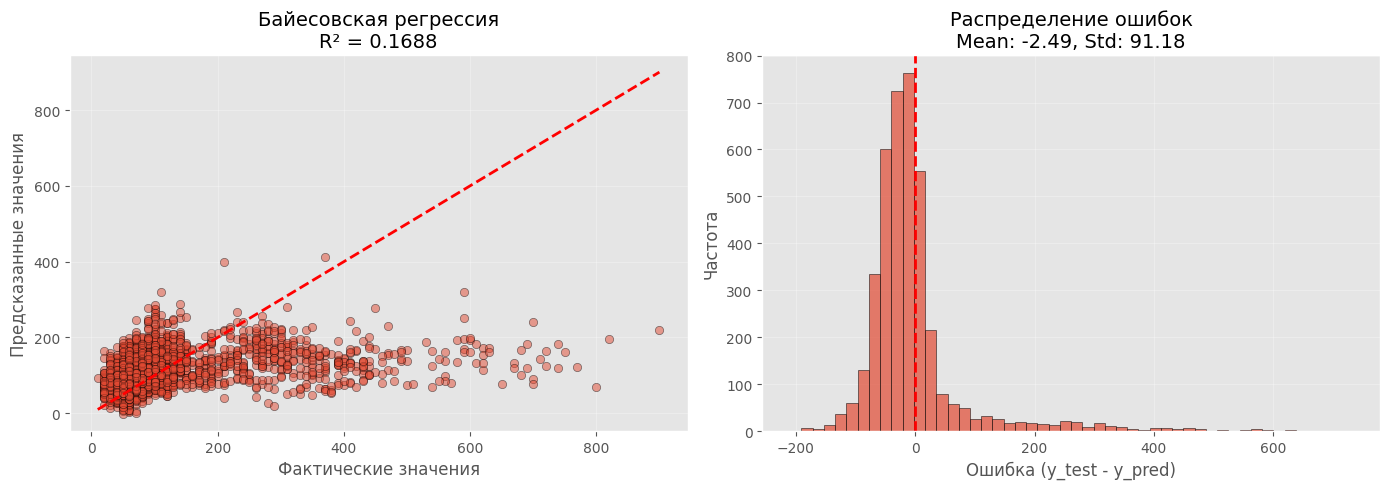

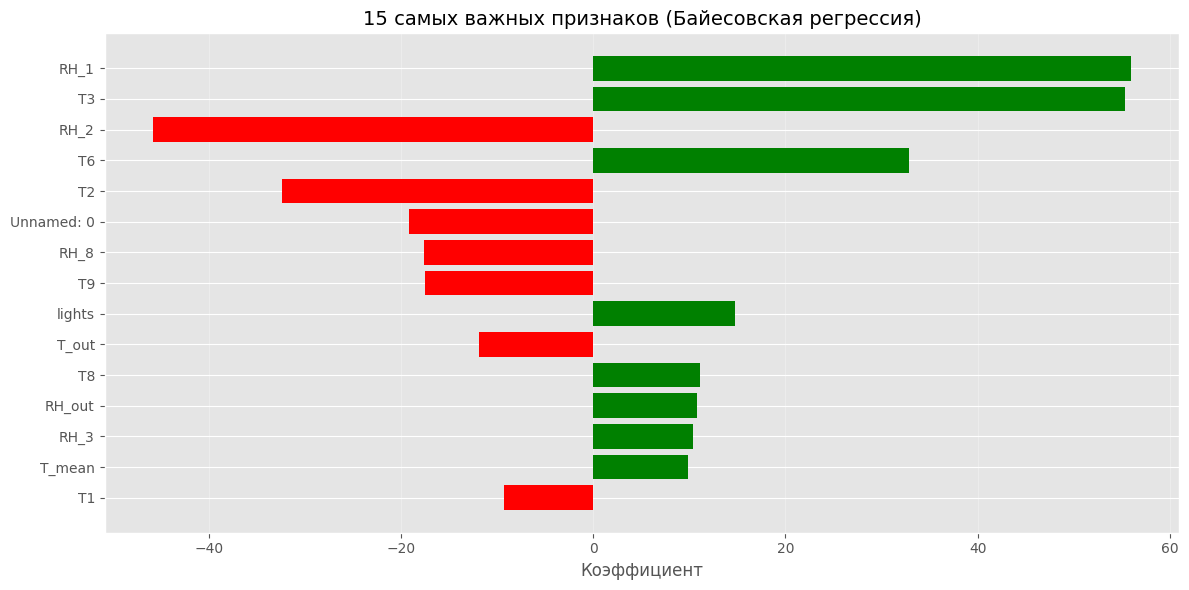

In [64]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_bayes, alpha=0.5, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f'Байесовская регрессия\nR² = {r2_bayes:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

errors_bayes = y_test - y_pred_bayes
axes[1].hist(errors_bayes, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (y_test - y_pred)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение ошибок\nMean: {errors_bayes.mean():.2f}, Std: {errors_bayes.std():.2f}', fontsize=14)
axes[1].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

if hasattr(bayesian_model, 'coef_'):
    plt.figure(figsize=(12, 6))
    coef_df = pd.DataFrame({
        'Признак': df_X.columns,
        'Коэффициент': bayesian_model.coef_
    }).sort_values('Коэффициент', key=abs, ascending=False)
        
    top_15 = coef_df.head(15)
    colors = ['green' if c >= 0 else 'red' for c in top_15['Коэффициент']]
    plt.barh(range(len(top_15)), top_15['Коэффициент'], color=colors)
    plt.yticks(range(len(top_15)), top_15['Признак'])
    plt.xlabel('Коэффициент', fontsize=12)
    plt.title('15 самых важных признаков (Байесовская регрессия)', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

Важность признака в модели определяется не только корреляцией: RH_1 даёт уникальный вклад при контроле остальных переменных, тогда как влияние lights может дублироваться другими факторами (мультиколлинеарность).

Байесовская регуляризация также могла сильнее сжать коэффициент lights, что сделало RH_1 статистически более значимым в итоговой модели.

---
## 3.5 Робастная регрессия
---

In [65]:
from sklearn.linear_model import HuberRegressor, RANSACRegressor

huber_model = HuberRegressor(max_iter=1000)
huber_model.fit(X_train_scaled, y_train)
y_pred_huber = huber_model.predict(X_test_scaled)

ransac_model = RANSACRegressor(estimator=LinearRegression(), random_state=42)
ransac_model.fit(X_train_scaled, y_train)
y_pred_ransac = ransac_model.predict(X_test_scaled)

def calculate_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    }

huber_metrics = calculate_metrics(y_test, y_pred_huber)
ransac_metrics = calculate_metrics(y_test, y_pred_ransac)

print("=" * 60)
print("РОБАСТНАЯ РЕГРЕССИЯ")
print("=" * 60)
print("\nМодель Huber:")
print(f"  R²:  {huber_metrics['R2']:.4f}")
print(f"  RMSE: {huber_metrics['RMSE']:.4f}")
print(f"  MAE: {huber_metrics['MAE']:.4f}")
print("\nМодель RANSAC:")
print(f"  R²:  {ransac_metrics['R2']:.4f}")
print(f"  RMSE: {ransac_metrics['RMSE']:.4f}")
print(f"  MAE: {ransac_metrics['MAE']:.4f}")

РОБАСТНАЯ РЕГРЕССИЯ

Модель Huber:
  R²:  0.0634
  RMSE: 96.8105
  MAE: 43.0367

Модель RANSAC:
  R²:  -0.6966
  RMSE: 130.3016
  MAE: 86.4998


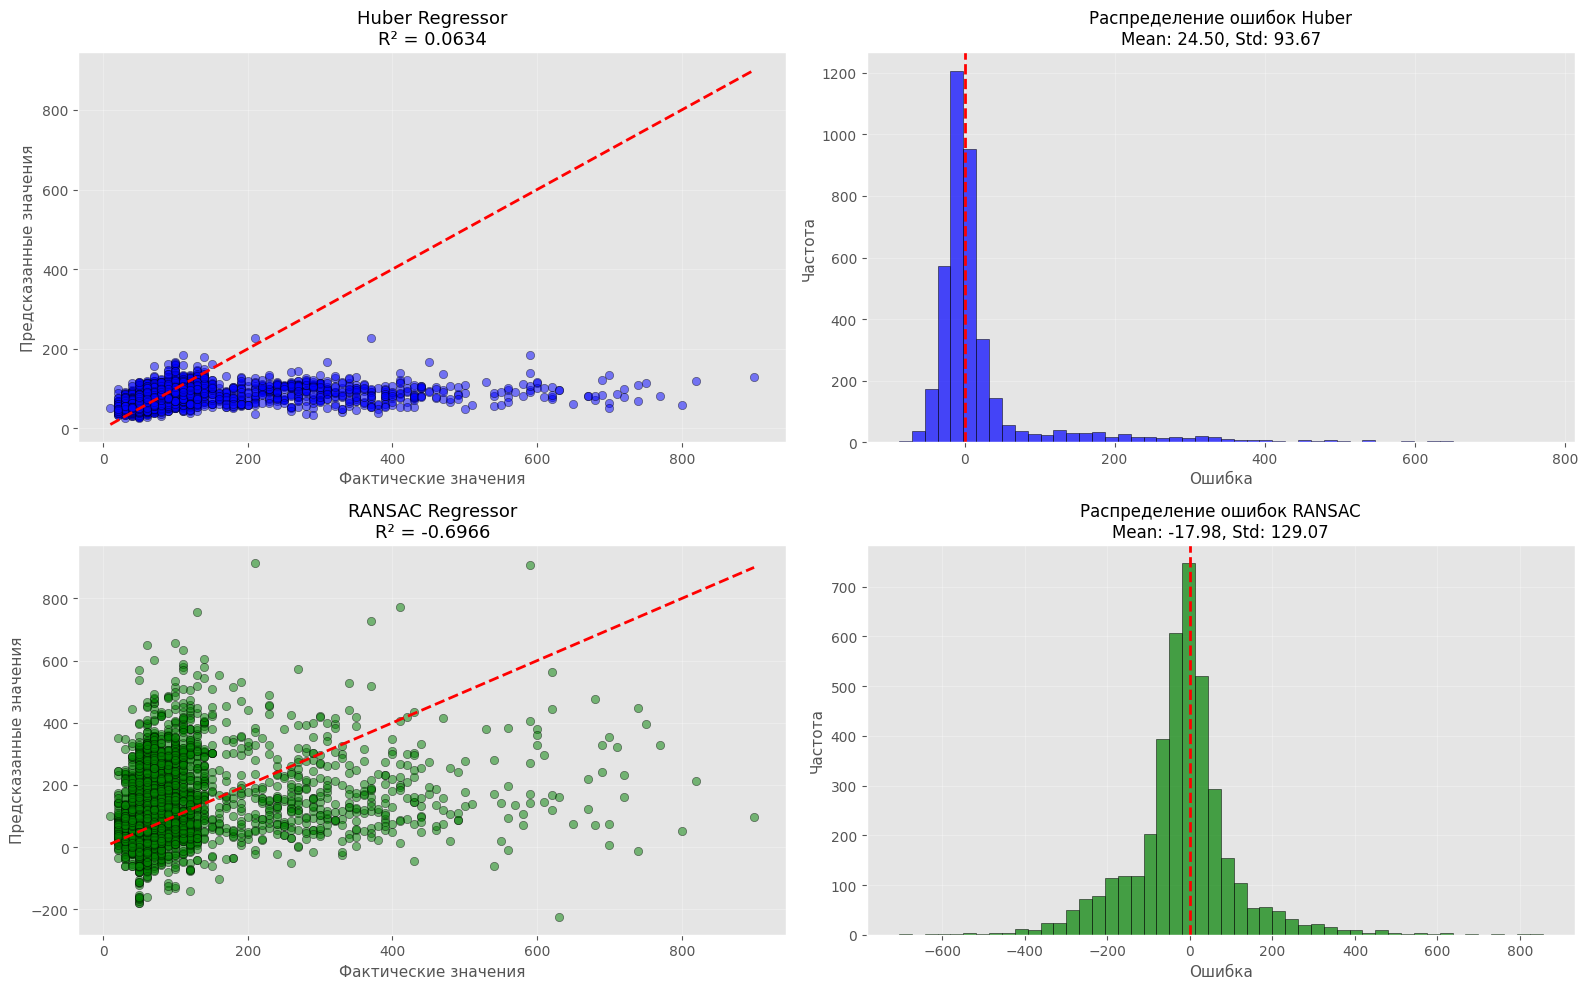

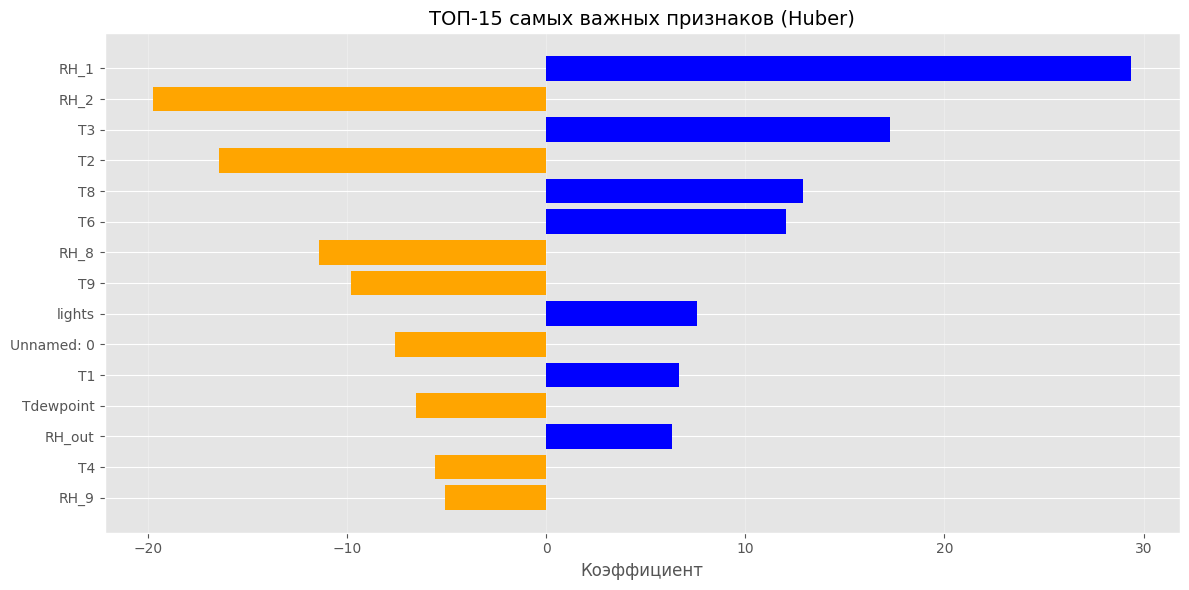

In [66]:
  
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].scatter(y_test, y_pred_huber, alpha=0.5, edgecolors='k', color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения', fontsize=11)
axes[0, 0].set_ylabel('Предсказанные значения', fontsize=11)
axes[0, 0].set_title(f'Huber Regressor\nR² = {huber_metrics["R2"]:.4f}', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

errors_huber = y_test - y_pred_huber
axes[0, 1].hist(errors_huber, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Ошибка', fontsize=11)
axes[0, 1].set_ylabel('Частота', fontsize=11)
axes[0, 1].set_title(f'Распределение ошибок Huber\nMean: {errors_huber.mean():.2f}, Std: {errors_huber.std():.2f}', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(y_test, y_pred_ransac, alpha=0.5, edgecolors='k', color='green')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Фактические значения', fontsize=11)
axes[1, 0].set_ylabel('Предсказанные значения', fontsize=11)
axes[1, 0].set_title(f'RANSAC Regressor\nR² = {ransac_metrics["R2"]:.4f}', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)
    
errors_ransac = y_test - y_pred_ransac
axes[1, 1].hist(errors_ransac, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Ошибка', fontsize=11)
axes[1, 1].set_ylabel('Частота', fontsize=11)
axes[1, 1].set_title(f'Распределение ошибок RANSAC\nMean: {errors_ransac.mean():.2f}, Std: {errors_ransac.std():.2f}', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()
    
if hasattr(huber_model, 'coef_'):
    plt.figure(figsize=(12, 6))
    coef_huber = pd.DataFrame({
        'Признак': df_X.columns,
        'Коэффициент': huber_model.coef_
    }).sort_values('Коэффициент', key=abs, ascending=False)
        
    top_15_huber = coef_huber.head(15)
    colors_huber = ['blue' if c >= 0 else 'orange' for c in top_15_huber['Коэффициент']]
    plt.barh(range(len(top_15_huber)), top_15_huber['Коэффициент'], color=colors_huber)
    plt.yticks(range(len(top_15_huber)), top_15_huber['Признак'])
    plt.xlabel('Коэффициент', fontsize=12)
    plt.title('ТОП-15 самых важных признаков (Huber)', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

if hasattr(ransac_model.estimator, 'coef_'):
    plt.figure(figsize=(12, 6))
    coef_ransac = pd.DataFrame({
        'Признак': df_X.columns,
        'Коэффициент': ransac_model.estimator.coef_
    }).sort_values('Коэффициент', key=abs, ascending=False)
        
    top_15_ransac = coef_ransac.head(15)
    colors_ransac = ['green' if c >= 0 else 'purple' for c in top_15_ransac['Коэффициент']]
    plt.barh(range(len(top_15_ransac)), top_15_ransac['Коэффициент'], color=colors_ransac)
    plt.yticks(range(len(top_15_ransac)), top_15_ransac['Признак'])
    plt.xlabel('Коэффициент', fontsize=12)
    plt.title('ТОП-15 самых важных признаков (RANSAC)', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

### Оптимизация гиперпараметров модели Huber с помощью Optuna

In [67]:
# === HuberRegressor: GridSearchCV ===
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid_huber = {
    'epsilon': [1.1, 1.2, 1.35, 1.5],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

grid_huber = GridSearchCV(
    estimator=HuberRegressor(max_iter=1000),
    param_grid=param_grid_huber,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_huber.fit(X_train_scaled, y_train)

print("GridSearchCV (HuberRegressor) завершён")
print(f"Лучшие параметры: {grid_huber.best_params_}")
print(f"Лучший R² (CV):   {grid_huber.best_score_:.4f}\n")

# === HuberRegressor: RandomizedSearchCV ===
param_dist_huber = {
    'epsilon': np.linspace(1.05, 1.5, 20),
    'alpha': np.logspace(-5, -1, 30)
}

rand_huber = RandomizedSearchCV(
    estimator=HuberRegressor(max_iter=1000),
    param_distributions=param_dist_huber,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rand_huber.fit(X_train_scaled, y_train)

print("RandomizedSearchCV (HuberRegressor) завершён")
print(f"Лучшие параметры: {rand_huber.best_params_}")
print(f"Лучший R² (CV):   {rand_huber.best_score_:.4f}\n")

# === HuberRegressor: Optuna ===
import optuna

def huber_objective(trial):
    epsilon = trial.suggest_float('epsilon', 1.05, 1.5)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    model = HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    return r2_score(y_test, model.predict(X_test_scaled))

huber_study = optuna.create_study(direction='maximize')
huber_study.optimize(huber_objective, n_trials=30, show_progress_bar=True)

print("\n" + "=" * 60)
print("ЛУЧШИЕ ПАРАМЕТРЫ МОДЕЛИ HUBER")
print("=" * 60)
print(f"Лучший R²: {huber_study.best_value:.4f}")
print(f"epsilon: {huber_study.best_params['epsilon']}")
print(f"alpha: {huber_study.best_params['alpha']}")

GridSearchCV (HuberRegressor) завершён
Лучшие параметры: {'alpha': 1e-05, 'epsilon': 1.5}
Лучший R² (CV):   0.0587



[I 2026-04-14 00:02:34,676] A new study created in memory with name: no-name-7c588a11-46c8-4377-ae98-4c276160cd9a


RandomizedSearchCV (HuberRegressor) завершён
Лучшие параметры: {'epsilon': np.float64(1.5), 'alpha': np.float64(0.005736152510448681)}
Лучший R² (CV):   0.0587



  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-14 00:02:34,861] Trial 0 finished with value: 0.058041406487620684 and parameters: {'epsilon': 1.2605812350655947, 'alpha': 0.0036909979374272353}. Best is trial 0 with value: 0.058041406487620684.
[I 2026-04-14 00:02:35,022] Trial 1 finished with value: 0.05650344837248178 and parameters: {'epsilon': 1.2339898744082163, 'alpha': 0.024149844846375647}. Best is trial 0 with value: 0.058041406487620684.
[I 2026-04-14 00:02:35,181] Trial 2 finished with value: 0.056592976751656976 and parameters: {'epsilon': 1.2351388010829998, 'alpha': 0.013032668991340791}. Best is trial 0 with value: 0.058041406487620684.
[I 2026-04-14 00:02:35,340] Trial 3 finished with value: 0.07167507841643195 and parameters: {'epsilon': 1.4720526324337557, 'alpha': 0.012277106261263476}. Best is trial 3 with value: 0.07167507841643195.
[I 2026-04-14 00:02:35,460] Trial 4 finished with value: 0.04869217666490799 and parameters: {'epsilon': 1.0585088720671407, 'alpha': 0.0009292962273953977}. Best is tria

---
## 5. ПОЛЬЗОВАТЕЛЬСКИЕ ФУНКЦИИ ОЦЕНКИ КАЧЕСТВА
---

In [68]:
from metrics import evaluate_model_custom

ModuleNotFoundError: No module named 'metrics'

---
## 5. ТАБЛИЦЫ РЕЗУЛЬТАТОВ
---

In [ ]:
all_models_results = {
    'Linear Regression': {'model': lr_model, 'y_pred': y_pred_lr, 'R2': r2_lr},
    'Lasso': {'model': lasso_model, 'y_pred': y_pred_lasso, 'R2': r2_lasso},
    'Ridge': {'model': ridge_model, 'y_pred': y_pred_ridge, 'R2': r2_ridge},
    'ElasticNet': {'model': elastic_model, 'y_pred': y_pred_elastic, 'R2': r2_elastic},
    'Polynomial ElasticNet': {'model': poly_model, 'y_pred': y_pred_poly, 'R2': r2_poly},
    'Bayesian': {'model': bayesian_model, 'y_pred': y_pred_bayes, 'R2': r2_bayes},
    'Huber': {'model': huber_model, 'y_pred': y_pred_huber, 'R2': huber_metrics['R2']},
    'RANSAC':{'model': ransac_model, 'y_pred': y_pred_ransac, 'R2': ransac_metrics['R2']}
    
}

results_data = []
for name, data in all_models_results.items():
    y_train_pred = data['model'].predict(X_train_scaled)
    row = {
        'Регрессор': name,
        'Train_R2': data['model'].score(X_train_scaled, y_train),
        'Test_R2': data['R2'],
        'Test_MSE': mean_squared_error(y_test, data['y_pred']),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, data['y_pred'])),
        'Test_MAE': mean_absolute_error(y_test, data['y_pred']),
        'Test_MAPE': np.mean(np.abs((y_test - data['y_pred']) / (y_test + 1e-10))) * 100
    }
    results_data.append(row)

results_df = pd.DataFrame(results_data)
print("Образец 1: Сравнение метрик на Train и Test выборках")
print("=" * 100)

def safe_format(x):
    try:
        return f'{x:.4f}'
    except (TypeError, ValueError):
        return x

display(results_df.style.format(safe_format).set_table_attributes('border="1"'))

In [ ]:
# Создаем DataFrame для сравнения (Образец 2)
comparison_data = []
for name, data in all_models_results.items():
    sk_metrics = {
        'R2': data['R2'],
        'MSE': mean_squared_error(y_test, data['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(y_test, data['y_pred'])),
        'MAE': mean_absolute_error(y_test, data['y_pred']),
        'MAPE': np.mean(np.abs((y_test - data['y_pred']) / (y_test + 1e-10))) * 100
    }
    custom_metrics = evaluate_model_custom(y_test, data['y_pred'])
    
    row = {
        'Регрессор': name,
        'SK_R2': sk_metrics['R2'], 'SK_MSE': sk_metrics['MSE'], 'SK_RMSE': sk_metrics['RMSE'],
        'SK_MAE': sk_metrics['MAE'], 'SK_MAPE': sk_metrics['MAPE'],
        'Custom_R2': custom_metrics['R2'], 'Custom_MSE': custom_metrics['MSE'],
        'Custom_RMSE': custom_metrics['RMSE'], 'Custom_MAE': custom_metrics['MAE'],
        'Custom_MAPE': custom_metrics['MAPE']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\nОбразец 2: Сравнение Scikit-learn и пользовательских функций")
print("=" * 100)

def safe_format(x):
    try:
        return f'{x:.4f}'
    except (TypeError, ValueError):
        return x

display(comparison_df.style.format(safe_format).set_table_attributes('border="1"'))

In [ ]:
model_names = list(all_models_results.keys())
r2_scores = [data['R2'] for data in all_models_results.values()]

plt.figure(figsize=(12, 6))
bars = plt.barh(model_names, r2_scores, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
plt.xlabel('R² Score (Test)')
plt.title('Сравнение моделей по R²')
plt.grid(True, alpha=0.3, axis='x')

for bar, score in zip(bars, r2_scores):
    plt.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()





---
## 7. ВЫВОДЫ И ЛУЧШАЯ МОДЕЛЬ
---

In [ ]:
best_model_name = max(all_models_results.keys(), key=lambda k: all_models_results[k]['R2'])
best_model = all_models_results[best_model_name]

print("=" * 80)
print("ВЫВОД")
print("=" * 80)
print(f"\nЛучшая модель регрессии: {best_model_name}")
print(f"\nМетрики на тестовой выборке:")
print(f"  R²:   {best_model['R2']:.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, best_model['y_pred'])):.2f} Вт·ч")
print(f"  MAE:  {mean_absolute_error(y_test, best_model['y_pred']):.2f} Вт·ч")

train_r2 = best_model['model'].score(X_train_scaled, y_train)
test_r2 = best_model['R2']
print(f"\nПроверка на переобучение:")
print(f"  R² на обучении: {train_r2:.4f}")
print(f"  R² на тесте:    {test_r2:.4f}")
print(f"  Разница:        {abs(train_r2 - test_r2):.4f}")
if abs(train_r2 - test_r2) < 0.05:
    print("Переобучение отсутствует")
else:
    print("Возможно переобучение")

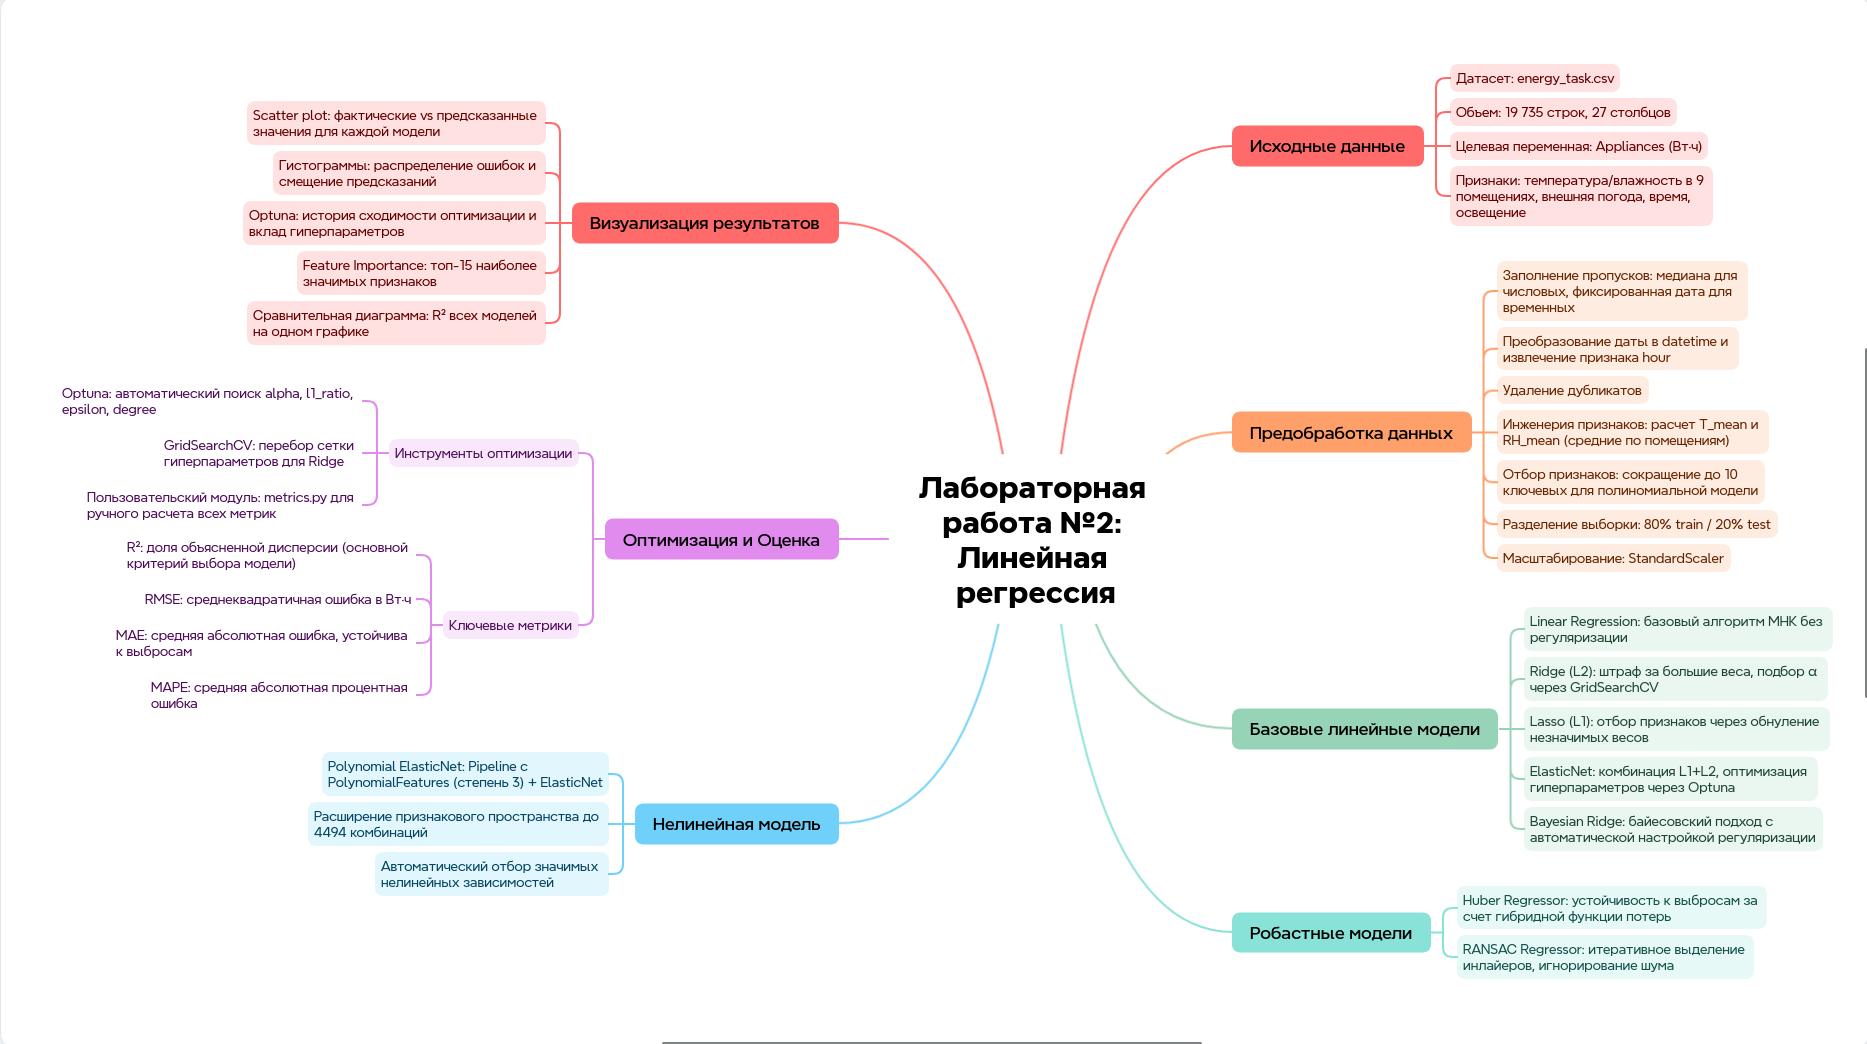

## ВЫВОД
В ходе выполнения лабораторной работы была решена задача прогнозирования энергопотребления бытовых приборов на основе данных о микроклимате помещений и внешних погодных условиях. Сравнительный анализ показал, что базовые линейные модели (Linear, Ridge, Lasso, ElasticNet, Bayesian) демонстрируют схожие и невысокие результаты (R² ≈ 0.17), что указывает на наличие сложных нелинейных взаимосвязей в данных. Введение полиномиальных признаков третьей степени в сочетании с ElasticNet-регуляризацией позволило существенно улучшить качество прогноза (R² ≈ 0.3486, MAE ≈ 44.96 Вт·ч), однако заметный разрыв между метриками на обучающей (R² ≈ 0.4954) и тестовой выборках свидетельствует о склонности модели к переобучению, характерном для высокоразмерных полиномиальных пространств.

Таким образом, наилучшие результаты показала полиномиальная регуляризованная регрессия, подтвердив важность учёта нелинейных взаимодействий признаков при моделировании энергопотребления. Для дальнейшего повышения обобщающей способности и устойчивости модели целесообразно применить продвинутые методы отбора признаков, кросс-валидацию с настройкой степени полинома или перейти к ансамблевым алгоритмам (например, Gradient Boosting), а также добавить временные признаки (день недели, сезонность) для более полного учёта сезонных паттернов потребления.